# Test de YOLOv8 sur la détection Chats vs Chiens
Ce notebook permet de tester les performances du modèle YOLOv8

In [5]:
from ultralytics import YOLO
import torchvision.transforms as T
import torch.utils.data as data
import torchvision.datasets as datasets
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1. Vérification du Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")


Using device: cuda


In [6]:
# 2. Chargement du modèle YOLOv8 pré-entraîné (COCO)
model = YOLO("yolov8n.pt")
model.to(device)

# 3. Préparation des données de test
# Correction : On ajoute Resize pour éviter l'erreur de taille des tenseurs
transform = T.Compose([
    T.Resize((640, 640)),
    T.ToTensor()
])

test_dataset = datasets.ImageFolder(root='../data/clean/test', transform=transform)
test_loader = data.DataLoader(test_dataset, batch_size=1, shuffle=False)

print(f"Classes détectées par ImageFolder : {test_dataset.class_to_idx}")
# Mapping local (0: Cat, 1: Dog) -> COCO (15: cat, 16: dog)
# On adapte selon les noms de dossiers détectés
local_to_coco = {}
for name, idx in test_dataset.class_to_idx.items():
    if 'cat' in name.lower():
        local_to_coco[idx] = 15
    elif 'dog' in name.lower():
        local_to_coco[idx] = 16

Classes détectées par ImageFolder : {'Cat': 0, 'Dog': 1}


In [7]:
# 4. Inférence et collecte des résultats
y_true = []
y_pred = []

print("Exécution de l'inférence sur le jeu de test...")
for img, label in test_loader:
    img = img.to(device)
    label_coco = local_to_coco[label.item()]
    
    # Prediction
    results = model(img, verbose=False)
    
    best_conf = -1
    pred_class = -1 # -1 signifie 'Aucune détection Cat/Dog'
    
    for r in results:
        for box in r.boxes:
            cls = int(box.cls.item())
            conf = box.conf.item()
            # On ne garde que les classes Cat (15) et Dog (16)
            if cls in [15, 16] and conf > best_conf:
                best_conf = conf
                pred_class = cls
    
    y_true.append(label_coco)
    y_pred.append(pred_class)

Exécution de l'inférence sur le jeu de test...


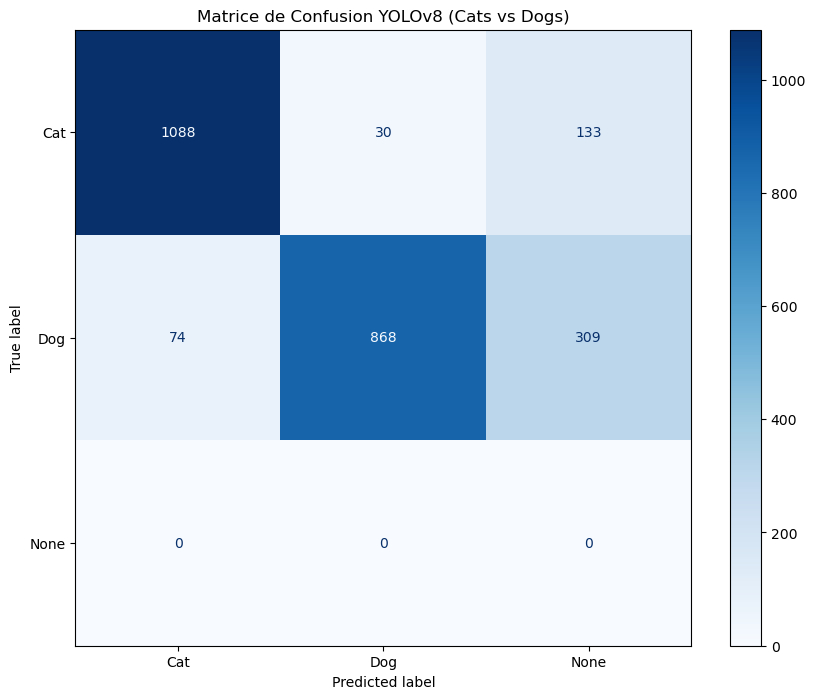

Précision globale (incluant les non-détections) : 78.18%


In [8]:
# 5. Matrice de Confusion
labels = [15, 16, -1]
display_labels = ["Cat", "Dog", "None"]

cm = confusion_matrix(y_true, y_pred, labels=labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=display_labels)

fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(ax=ax, cmap='Blues', values_format='d')
plt.title("Matrice de Confusion YOLOv8 (Cats vs Dogs)")
plt.show()


y_true_np = np.array(y_true)
y_pred_np = np.array(y_pred)
accuracy = np.mean(y_true_np == y_pred_np)
print(f"Précision globale (incluant les non-détections) : {accuracy:.2%}")